In [8]:
import pandas as pd

df = pd.read_csv("final_merged_data.csv")
df['date'] = pd.to_datetime(df['date'])

print(df.head())

        date     product  demand  lead_time_days  material_available  \
0 2023-01-08  Headphones     145               4                 136   
1 2023-01-09  Headphones     147               6                 209   
2 2023-01-10  Headphones     150               6                 160   
3 2023-01-11  Headphones     167               4                 222   
4 2023-01-12  Headphones     161               3                 136   

   supplier_delay  machine_capacity  machine_downtime  labor_available  \
0               0               172                 0              117   
1               0               248                 0               95   
2               1               154                 1              101   
3               0               188                 0              137   
4               0               220                 1              163   

   absenteeism  effective_labor  effective_capacity  effective_material  \
0            0            117.0               1

In [9]:
df = pd.get_dummies(df, columns=['product'])
df.tail()

,date,demand,lead_time_days,material_available,supplier_delay,machine_capacity,machine_downtime,labor_available,absenteeism,effective_labor,...,effective_material,month,day_of_week,lag_1,lag_7,product_Headphones,product_Laptop,product_Smartphone,product_Smartwatch,product_Tablet
1785,2023-12-27,206,3,186,0,167,0,127,1,101.6,...,186.0,12,2,209.0,199.0,False,False,False,False,True
1786,2023-12-28,217,6,190,0,214,0,94,0,94.0,...,190.0,12,3,206.0,217.0,False,False,False,False,True
1787,2023-12-29,216,2,163,0,194,0,125,0,125.0,...,163.0,12,4,217.0,198.0,False,False,False,False,True
1788,2023-12-30,217,7,145,0,212,0,162,0,162.0,...,145.0,12,5,216.0,199.0,False,False,False,False,True
1789,2023-12-31,212,4,229,0,122,0,93,0,93.0,...,229.0,12,6,217.0,204.0,False,False,False,False,True


In [10]:
features = [
    'lag_1',
    'lag_7',
    'month',
    'day_of_week',
    'effective_labor',
    'effective_capacity',
    'effective_material'
] + [col for col in df.columns if col.startswith('product_')]

target = 'demand'

In [11]:
train_list = []
test_list = []

for product in df.filter(like='product_').columns:
    
    temp = df[df[product] == 1].sort_values('date')
    
    split_index = int(len(temp) * 0.8)
    
    train_list.append(temp.iloc[:split_index])
    test_list.append(temp.iloc[split_index:])

train = pd.concat(train_list)
test = pd.concat(test_list)

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, random_state=42)

In [13]:
predictions = model.predict(X_test)

print(predictions[:10])

[221.89015278 225.71807937 229.73740637 238.39301881 247.37662687
 241.6873414  245.63162698 242.66513777 248.39690909 248.61284799]


In [14]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 11.191451450712435


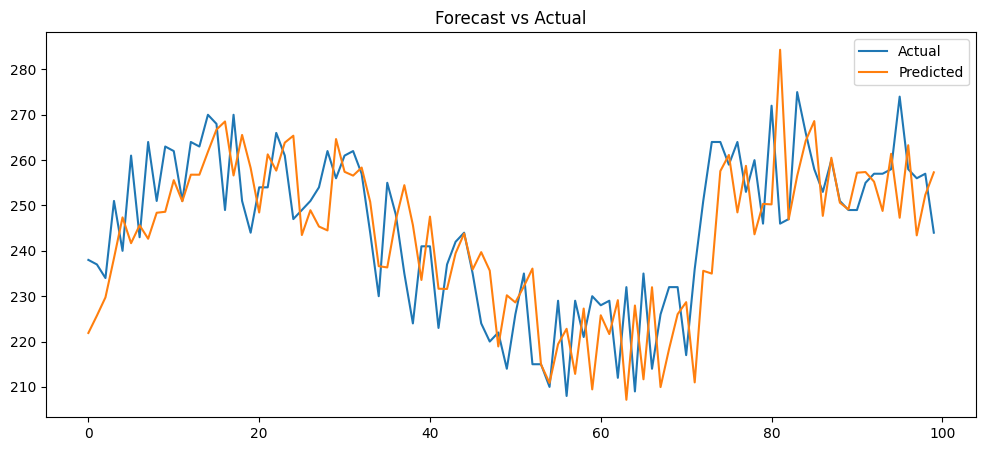

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(predictions[:100], label="Predicted")

plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [16]:
df_test = X_test.copy()
df_test['actual_demand'] = y_test.values
df_test['predicted_demand'] = predictions

In [17]:
def calculate_production(row):
    return min(
        row['predicted_demand'],
        row['effective_capacity'],
        row['effective_material'],
        row['effective_labor']
    )

df_test['production_plan'] = df_test.apply(calculate_production, axis=1)

In [18]:
def identify_bottleneck(row):
    constraints = {
        'capacity': row['effective_capacity'],
        'material': row['effective_material'],
        'labor': row['effective_labor']
    }
    
    return min(constraints, key=constraints.get)

df_test['bottleneck'] = df_test.apply(identify_bottleneck, axis=1)

In [19]:
df_test['production_gap'] = df_test['predicted_demand'] - df_test['production_plan']

In [20]:
print(df_test[['predicted_demand', 'production_plan', 'bottleneck', 'production_gap']].head())

     predicted_demand  production_plan bottleneck  production_gap
286        221.890153             93.0      labor      128.890153
287        225.718079            109.0      labor      116.718079
288        229.737406             92.0      labor      137.737406
289        238.393019            135.6   material      102.793019
290        247.376627            136.0      labor      111.376627


In [21]:
pip install pulp

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/16.4 MB 20.2 MB/s eta 0:00:01
   ----------- ---------------------------- 4.7/16.4 MB 11.9 MB/s eta 0:00:01
   --------------- ------------------------ 6.3/16.4 MB 10.7 MB/s eta 0:00:01
   ------------------ --------------------- 7.6/16.4 MB 11.2 MB/s eta 0:00:01
   ------------------ --------------------- 7.6/16.4 MB 11.2 MB/s eta 0:00:01
   ------------------- -------------------- 7.9/16.4 MB 6.8 MB/s eta 0:00:02
   ---------------------------- ----------- 11.8/16.4 MB 8.0 MB/s eta 0:00:01
   ----------------------------------- ---- 14.4/16.4 MB 8.5 MB/s eta 0:00:01
   ------------------------------------- -- 15.2/16.4 MB 8.9 MB/s eta 0:00:01
   ------------------------------------- -- 15.2/16.4 MB 8.9 MB/s eta 0:00:01
   ------------------------------------- -- 15.2/16.4 MB 8.9 MB/s eta 0:00:01
   ------------------------------------- -- 15.2/16.4 MB 8.9 MB/s eta 0:0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
